# Will contests are disappearing from Florida appellate opinions

**Testamentary capacity and undue influence, 1960 to 2026**

Kevin D. Klagge, Esq. · [StepUpLaw](https://stepuplaw.com) · [ORCID 0009-0002-1385-8498](https://orcid.org/0009-0002-1385-8498)

---

Two doctrines decide most Florida will contests. **Testamentary capacity** asks
whether the testator understood what they owned and who their natural
beneficiaries were. **Undue influence** asks whether someone else's will was
substituted for theirs.

This notebook measures how often Florida appellate courts write about them, and
finds that the rate has fallen by roughly three quarters since the 1980s. The
raw counts alone would not show this, because the corpus itself grew — so the
whole analysis turns on normalising against a denominator.

**What this is not.** This measures how often courts *discuss* these doctrines,
not how often litigants *win* on them. Determining outcomes requires reading
each opinion. Treat it as a map of where the law is being argued, not a
success-rate study.

## Data

The [CourtListener](https://www.courtlistener.com/) bulk corpus, snapshot
2026-06-30: 10,797,793 opinions across 10,070,727 clusters, stored locally with
an SQLite FTS5 index. A *cluster* is one decision, which may contain a majority
opinion plus concurrences and dissents; counting clusters rather than opinions
avoids counting one decision several times.

Queries go through `clcorpus`, the shared corpus library, rather than opening
the database directly. That is not a style preference: the library owns the
court-scope definitions, the `?immutable=1` open, and the block decoder, each of
which is easy to get subtly wrong. Its `fl` scope also resolves to a local SSD
slice, so the same query that takes seconds against the full corpus returns
almost instantly.

Reproducing this from scratch needs the corpus. The derived counts this notebook
produces are written to CSV alongside it, so the results are reusable without
it.

In [1]:
import collections
import pathlib
import sys

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(pathlib.Path.home() / "caselaw"))
import clcorpus as cc  # noqa: E402  the shared corpus library

db, info = cc.connect(scope="fl", quiet=True)

# Florida STATE appellate courts only: the District Courts of Appeal and the
# Supreme Court of Florida. Federal courts sitting in Florida are excluded on
# purpose — they hear almost no will contests, and their share of the corpus
# grew over the period, which would otherwise dilute the denominator and
# manufacture a decline that is really a change in corpus composition.
COURTS = ["fladistctapp", "fla"]
qm = ",".join("?" * len(COURTS))
snapshot = db.execute("SELECT v FROM meta WHERE k='source_snapshot'").fetchone()[0]
print(f"corpus:   {info['ops']}")
print(f"snapshot: {snapshot}")

corpus:   /Users/user/beastmode-data/fl-opinions.db
snapshot: 2026-06-30


## Query

FTS5 phrase matching. "Lucid interval" is included because it is the standard
term for capacity at the moment of execution, and an opinion can turn on it
without using the phrase "testamentary capacity" nearby.

A caveat that limits every text search of this kind: a match means the phrase
appears somewhere in the decision. Some hits will be passing citations rather
than holdings. The measure is therefore an upper bound on doctrinal engagement,
and it is only meaningful because the same bias applies across every decade.

In [2]:
QUERIES = {
    "testamentary capacity": '"testamentary capacity" OR "lucid interval"',
    "undue influence": '"undue influence"',
}

def clusters(query):
    """Opinion ids from the FTS index, resolved to decisions in our two courts."""
    ids = cc.fts_ids(db, query)
    q = ",".join("?" * len(ids))
    rows = db.execute(
        f"""SELECT DISTINCT o.cluster_id
            FROM opinions o
            JOIN cluster_court cc ON cc.cluster_id = o.cluster_id
            WHERE o.id IN ({q}) AND cc.court IN ({qm})""",
        (*ids, *COURTS),
    ).fetchall()
    return {r[0] for r in rows}

sets = {k: clusters(q) for k, q in QUERIES.items()}
both = sets["testamentary capacity"] & sets["undue influence"]
either = sets["testamentary capacity"] | sets["undue influence"]

for k, v in sets.items():
    print(f"{k:>24}: {len(v):>5,} decisions")
print(f"{'both doctrines':>24}: {len(both):>5,}")
print(f"{'either':>24}: {len(either):>5,}")
print(f"\noverlap: {len(both) / len(sets['testamentary capacity']):.0%} of capacity "
      f"decisions also raise undue influence")

   testamentary capacity:   251 decisions
         undue influence: 1,107 decisions
          both doctrines:   176
                  either: 1,182

overlap: 70% of capacity decisions also raise undue influence


## The denominator

Raw counts cannot answer "is this getting rarer," because the number of Florida
appellate decisions in the corpus is itself uneven across decades. Every count
below is expressed per 10,000 decisions from the same courts in the same
period.

In [3]:
def by_year(cluster_ids=None):
    counts = collections.Counter()
    if cluster_ids is None:
        rows = db.execute(
            f"""SELECT cm.date_filed FROM cluster_court cc
                JOIN cluster_meta cm ON cm.cluster_id = cc.cluster_id
                WHERE cc.court IN ({qm}) AND cm.date_filed IS NOT NULL""",
            COURTS,
        )
    else:
        ids = list(cluster_ids)
        q2 = ",".join("?" * len(ids))
        rows = db.execute(
            f"SELECT date_filed FROM cluster_meta WHERE cluster_id IN ({q2}) "
            "AND date_filed IS NOT NULL", ids,
        )
    for (d,) in rows:
        counts[int(d[:4])] += 1
    return counts

hits_y, base_y = by_year(either), by_year()

DECADES = [1960, 1970, 1980, 1990, 2000, 2010, 2020]
rows = []
for d in DECADES:
    n = sum(v for y, v in hits_y.items() if d <= y < d + 10)
    t = sum(v for y, v in base_y.items() if d <= y < d + 10)
    rows.append({"decade": f"{d}s", "decisions": n, "all_fl_appellate": t,
                 "per_10k": round(n / t * 10000, 1) if t else None})
df = pd.DataFrame(rows)
df

,decade,decisions,all_fl_appellate,per_10k
0,1960s,123,30788,40.0
1,1970s,137,45972,29.8
2,1980s,223,45771,48.7
3,1990s,142,51545,27.5
4,2000s,111,74817,14.8
5,2010s,116,112809,10.3
6,2020s,61,30995,19.7


## The finding

The rate falls from roughly 40 to 49 per 10,000 decisions in the 1960s through
1980s to between 10 and 20 from the 2000s onward. Florida appellate courts write
about these doctrines **about a quarter as often**, relative to their total
output, as they did at the peak.

The 1980s figure is the high point and the 2010s the low. The 2020s tick back up,
but that decade is incomplete and rests on a much smaller denominator, so it
should not be read as a reversal.

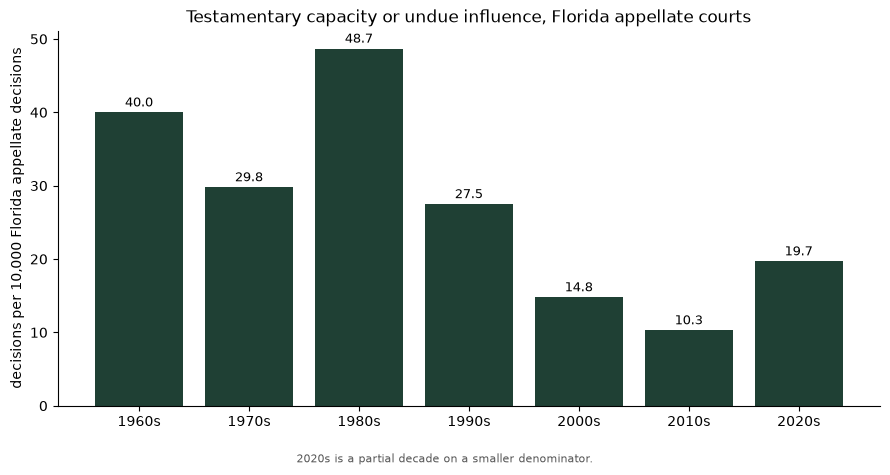

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(df["decade"], df["per_10k"], color="#1F4034")
ax.set_ylabel("decisions per 10,000 Florida appellate decisions")
ax.set_title("Testamentary capacity or undue influence, Florida appellate courts")
for i, v in enumerate(df["per_10k"]):
    ax.text(i, v + 0.8, str(v), ha="center", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
fig.text(0.5, -0.04, "2020s is a partial decade on a smaller denominator.",
         ha="center", fontsize=8, color="#555")
plt.tight_layout()
plt.show()

## Why the rate might be falling

The data supports the decline. It does not explain it, and these are hypotheses
rather than findings.

**Revocable trusts displaced wills.** A trust dispute is litigated under
chapter 736 and is often framed as breach of fiduciary duty rather than as a
capacity or undue influence challenge to a will. The doctrines may be as active
as ever while appearing under different vocabulary.

**Fewer contests reach an appellate opinion.** Mediation became mandatory in
Florida civil practice over this period, and a case that settles never produces
one.

**Corpus coverage.** CourtListener's Florida coverage is not uniformly deep
across sixty years. Restricting to state appellate courts controls for the
growth of federal opinions but not for uneven historical digitisation.

The trust hypothesis is testable with the same corpus, by measuring chapter 736
fiduciary language over the same period. That is the obvious next notebook.

In [5]:
# Export the derived counts so the results are reusable without the 2 GB corpus.
out = pathlib.Path("florida-capacity-undue-influence-by-decade.csv")
df.to_csv(out, index=False)

# Year-level series too, which is what anyone re-testing the trend would want.
years = pd.DataFrame(
    [{"year": y, "decisions": hits_y.get(y, 0), "all_fl_appellate": base_y.get(y, 0)}
     for y in range(1960, 2027)]
)
years["per_10k"] = (years["decisions"] / years["all_fl_appellate"] * 10000).round(2)
years.to_csv("florida-capacity-undue-influence-by-year.csv", index=False)
print(f"wrote {out} and florida-capacity-undue-influence-by-year.csv")
years.tail(8)

wrote florida-capacity-undue-influence-by-decade.csv and florida-capacity-undue-influence-by-year.csv


,year,decisions,all_fl_appellate,per_10k
59,2019,11,19054,5.77
60,2020,4,2534,15.79
61,2021,14,3454,40.53
62,2022,9,3967,22.69
63,2023,9,4621,19.48
64,2024,9,7075,12.72
65,2025,13,4848,26.82
66,2026,3,4496,6.67


## Reuse

Licensed [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/). The derived
CSVs carry the same licence. Cite as:

> Klagge, Kevin D. "Will contests are disappearing from Florida appellate
> opinions: testamentary capacity and undue influence, 1960 to 2026." StepUpLaw.

**Not legal advice.** This is empirical research about published opinions, not
guidance about any particular estate, and reading it creates no attorney-client
relationship.